# Momepy roads 

This notebook uses momepy to calculate geometrical features of the streets, such as width and openess.

## Import libraries

In [2]:
import momepy as mm
import geopandas as gpd
import osmnx as ox
import pandas as pd

## Import noise segments

In [3]:
edges = gpd.read_file("../../layers/bcn_osmnx_edges.gpkg")
print(edges.crs)  #CRS = Coordinate Reference System
print(edges.shape)
print(edges.columns.tolist())
print("Number of street segments:", len(edges))

EPSG:25831
(16541, 21)
['u', 'v', 'key', 'osmid', 'highway', 'lanes', 'maxspeed', 'name', 'oneway', 'reversed', 'length', 'access', 'junction', 'ref', 'width', 'est_width', 'tunnel', 'bridge', 'service', 'segment_id', 'geometry']
Number of street segments: 16541


## Import and project buildings

In [4]:
place_name = "Barcelona, Spain"
tags = {'building': True}

print("Downloading buildings from OSM...")
try:
    buildings = ox.features_from_place(place_name, tags)
except AttributeError:
    buildings = ox.geometries_from_place(place_name, tags)
    
# Project buildings to the same CRS as edges
buildings = buildings.to_crs(edges.crs)

## Create Momepy street profile

In [ ]:
building_buffer = buildings.buffer(5).union_all()
profile = mm.street_profile(edges, buildings)
profile.head(10)

,u,v,key,osmid,highway,lanes,maxspeed,name,oneway,reversed,...,width,est_width,tunnel,bridge,service,segment_id,geometry,road_width,road_it,road_id
0,21638845,885308258,0,554707785,residential,2,30,Passeig de Joan de Borbó,True,False,...,NaN,NaN,NaN,NaN,NaN,21638845_885308258_0,"LINESTRING (432071.186 4580160.408, 432067.928...",NaN,21638845_885308258_0,21638845_885308258_0
1,21638845,13175411896,0,"[1433594636, 4079500, 543357596, 902517725, 42...",residential,"['3', '4']",30,Passeig de Joan de Borbó,False,True,...,NaN,NaN,NaN,NaN,NaN,21638845_13175411896_0,"LINESTRING (432071.186 4580160.408, 432066.515...",NaN,21638845_13175411896_0,21638845_13175411896_0
2,21638865,30343650,0,4079505,living_street,NaN,20,Carrer del Judici,True,False,...,NaN,NaN,NaN,NaN,NaN,21638865_30343650_0,"LINESTRING (432319.661 4580899.827, 432307.059...",NaN,21638865_30343650_0,21638865_30343650_0
3,21638867,1636238503,0,4079509,tertiary,2,30,Carrer de Pepe Rubianes,False,True,...,NaN,NaN,NaN,NaN,NaN,21638867_1636238503_0,"LINESTRING (432179.146 4581060.543, 432163.986...",NaN,21638867_1636238503_0,21638867_1636238503_0
4,21638867,1403082237,0,4079509,tertiary,2,30,Carrer de Pepe Rubianes,False,False,...,NaN,NaN,NaN,NaN,NaN,21638867_1403082237_0,"LINESTRING (432179.146 4581060.543, 432185.166...",NaN,21638867_1403082237_0,21638867_1403082237_0


## Add geo features to noise streets

In [6]:
dataset = pd.DataFrame({
    "road_id": edges['segment_id'],
})
dataset['road_width'] = profile['width']
dataset['openness'] = profile['openness']
dataset.head(10)

,road_id,road_width,openness
0,21638845_885308258_0,43.025602,0.750000
1,21638845_13175411896_0,26.114886,0.363095
2,21638865_30343650_0,15.135908,0.750000
3,21638867_1636238503_0,18.154330,0.666667
4,21638867_1403082237_0,20.158620,0.666667
5,21638867_30343414_0,6.935241,0.333333
6,21638868_30343649_0,36.205524,0.833333
7,21638868_30343654_0,36.508301,0.833333
8,21638869_30343672_0,18.216613,0.666667
9,21638869_242318729_0,17.913847,0.666667


Text(0.5, 1.0, 'Total Street Width')

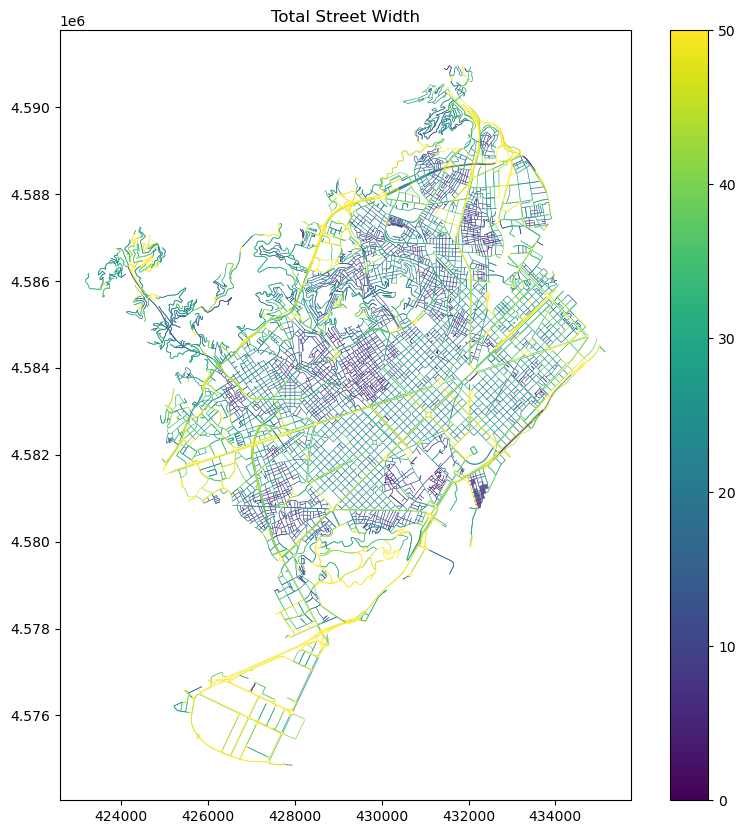

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))
edges.plot(column='road_width', linewidth=0.5, legend=True, ax=ax)
ax.set_title('Total Street Width')

## Export dataset to CSV

In [17]:
import os
output_dir = "../../data/processed"
os.makedirs(output_dir, exist_ok=True)
dataset.to_csv(os.path.join(output_dir, "momepy_streets.csv"), index=False)
print("Exported momepy_streets.csv")

Exported momepy_streets.csv


TODO: using building height we could also calculate street canyon height and h/w ratio, which are relevant for noise propagation.